In [522]:
import xarray as xr
import flox.xarray as fx
import numpy as np
import pandas as pd
import cmocean.cm as cmo
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import matplotlib.ticker as ticker
import oceanmixedlayers.oceanmixedlayers as oml
import oceanmixedlayers.threshold as td
import kneed

In [1018]:
ds_so = xr.open_dataset('/swot/SUM05/jpope/mld_threshold.nc', chunks = {'N_PROF': 10000})

### Useful Functions

In [670]:
def broken_new_mld_from_energies(pres, sig0, energies):
    """
    For an array of energies, returns an array of MLDs of the profile
    for those energies
    """
    
    mask = ~np.isnan(pres) & ~np.isnan(sig0)
    pres, sig0 = pres[mask], sig0[mask]
    # Filter for data below 10 m
    start_i = np.argmax(pres >= 10)
    pres = pres[start_i:]
    sig0 = sig0[start_i:]
    
    # Shallowest layer thickness (negative to match sign convention)
    dp_0 = -(pres[0] - 1)
    # Center of shallowest layer just half of thickness (and positive)
    p_0 = -(dp_0/2)
    
    # Thickness array
    dp = np.array([dp_0] + list(np.full_like(pres, -2.0)))
    
    # Arrays with extrapolated surface values
    pres = np.array([p_0] + list(pres))
    sig0 = np.array([sig0[0]] + list(sig0))
    
    # Adjust sig0 -> rho
    rho = sig0 + 1000
    # Adjust pres -> depth
    z = -pres
    dz = -dp
    
#     for x in [rho, z, dz]:
#         print(x)

    
    # Calculate MLDs
    MLDs = [oml.mld_pe_anomaly(z, dz, rho, gradient = False, 
                               energy = e).item() for e in energies]
    
    return np.array(MLDs)

In [676]:
def new_mld_from_energies(pres, sig0, energies):
    """
    For an array of energies, returns an array of MLDs of the profile
    for those energies
    """

    # Filter for data below 10 m
    start_i = np.argmax(pres >= 10)
    pres = pres[start_i:]
    sig0 = sig0[start_i:]
    
    P_i = np.array([0.] + list(pres))
    Z_i = -1. * P_i
    dZ = (Z_i[:-1] - Z_i[1:])
    sig0_i = np.array([sig0[0]] + list(sig0))
    rho0_i = sig0_i + 1000
    
    P_c = 0.5*(P_i[1:] + P_i[:-1])
    dP = (P_i[:-1] -P_i[1:])
    rho0_c = 0.5*(rho0_i[1:] +rho0_i[:-1])
    
    for zi in range(len(rho0_c)):
        Z_i[zi+1] = Z_i[zi] + 1.e4*dP[zi]/(9.81*rho0_c[zi])
        
    Z_c = 0.5*(Z_i[1:] + Z_i[:-1])
    dZ = (Z_i[:-1] - Z_i[1:])
    

#      Calculate MLDs
    MLDs = [oml.mld_pe_anomaly(Z_c, dZ, rho0_c, gradient = False, 
                               energy = e).item() for e in energies]
    
    return np.array(MLDs)

In [651]:
def mld_from_energies(pres, ct, sa, energies):
    """
    For an array of energies, returns an array of MLDs of the profile
    for those energies
    """
    # Filter for data below 10 m
    start_i = np.argmax(pres >= 10)
    pres = pres[start_i:]
    ct = ct[start_i:]
    sa = sa[start_i:]
    
    
    # Shallowest layer thickness (negative to match sign convention)
    dp_0 = -(pres[0] - 1)
    # Center of shallowest layer just half of thickness (and positive)
    p_0 = -(dp_0/2)
    
    # Thickness array
    dp = np.array([dp_0] + list(np.full_like(pres, -2.0)))
    
    # Arrays with extrapolated surface values
    pres = np.array([p_0] + list(pres))
    ct = np.array([ct[0]] + list(ct))
    sa = np.array([sa[0]] + list(sa))
    
    # Calculate MLDs
    MLDs = [oml.mld_delta_pe(pres, dp, ct, sa, coord = 'pressure',
                            energy = e).item() for e in energies]
    
    return np.array(MLDs)

In [652]:
def detect_knee_angle(x, y, window=1):
    """
    Detect knee point based on smallest angle between three consecutive points.

    Parameters
    ----------
    x : array-like
        Independent variable (e.g. energy).
    y : array-like
        Dependent variable (e.g. MLD).
    window : int
        How far before and after the center point to look (default: 1 = use i-1, i, i+1).

    Returns
    -------
    knee_idx : int
        Index of the knee point in the original data.
    angles : np.ndarray
        Array of angles (in radians) for each interior point.
    """
    x = np.asarray(x)
    y = np.asarray(y)
    n = len(x)
    angles = np.full(n, np.nan)  # initialize with NaNs

    for i in range(window, n - window):
        # Get three points: A (i-window), B (i), C (i+window)
        A = np.array([x[i - window], y[i - window]])
        B = np.array([x[i], y[i]])
        C = np.array([x[i + window], y[i + window]])

        # Vectors BA and BC
        BA = A - B
        BC = C - B

        # Angle at point B (in radians)
        cos_theta = np.dot(BA, BC) / (np.linalg.norm(BA) * np.linalg.norm(BC))
        # Clamp to [-1, 1] to avoid numerical issues
        cos_theta = np.clip(cos_theta, -1.0, 1.0)
        theta = np.arccos(cos_theta)

        angles[i] = theta

    # Knee is point with smallest angle (sharpest turn)
    knee_idx = np.nanargmin(angles)
    return knee_idx, angles

In [653]:
def get_mld(pres, ct, sa, energies):
    """
    For one profile, given a set of energies, finds where the energy flattens out most
    sharply on the energy vs depth plot, which is defined as the MLD
    
    Returns the mixed layer depth (MLD) and mixed layer energy (MLE), defined as the energy
    required to mix that profile to homogenous density from the surface to the MLD
    """
    try: 
        mld_values = mld_from_energies(pres, ct, sa, energies)
        knee_idx, _ = detect_knee_angle(energies, mld_values)
        MLD = mld_values[knee_idx]
        MLE = energies[knee_idx]
        return MLE, MLD
    
    except Exception:
        return np.nan, np.nan

---------------------------------------------

### Bulk Calculations

In [972]:

def prepare_profiles(pres, ct, sa):
    """
    Prepares profiles for energy-based MLD:
    Adds extrapolated surface layer and calculates thickness.
    
    Inputs:
        pres, ct, sa: arrays of shape (N_PROF, N_DEPTH) or (N_DEPTH,)
    
    Returns:
        pres_new, dp_new, ct_new, sa_new:
            shape (N_PROF, N_DEPTH+1) or (N_DEPTH+1,) for single profile
    """
    is_single_profile = pres.ndim == 1

    # If single profile, temporarily add a fake batch dim
    if is_single_profile:
        pres = pres[None, :]
        ct   = ct[None, :]
        sa   = sa[None, :]

    N_PROF, N_DEPTH = ct.shape

    pres_2d = np.broadcast_to(pres, (N_PROF, N_DEPTH))

    dp0 = -(pres_2d[:, 0] - 1)
    p0  = -dp0 / 2

    dp_rest = np.full((N_PROF, N_DEPTH), -2.0)
    dp_new = np.concatenate([dp0[:, None], dp_rest], axis=1)

    pres_new = np.concatenate([p0[:, None], pres_2d], axis=1)
    ct_new   = np.concatenate([ct[:, [0]], ct], axis=1)
    sa_new   = np.concatenate([sa[:, [0]], sa], axis=1)

    # If single profile, return squeezed arrays
    if is_single_profile:
        return (
            pres_new[0],
            dp_new[0],
            ct_new[0],
            sa_new[0],
        )

    return pres_new, dp_new, ct_new, sa_new


In [873]:
# pres_new, dp_new, ct_new, sa_new = prepare_profiles(pres_ex, ct_ex, sa_ex)

----------------------


-----

## Bulk Calculation Pipeline

In [945]:
ds_subset = ds_so
energies = np.logspace(0, 2.5, 100)

In [939]:
# Select profiles with valid data at 1000 dbar
sig0_at_10 = ds_subset['SIG0'].sel(PRES_INTERPOLATED=10, method='nearest')
valid_mask = ~np.isnan(sig0_at_10)
valid_indices = np.where(valid_mask.values)[0]

# Filter ds_subset to retain only those profiles
ds_filtered = ds_subset.isel(N_PROF=valid_indices)

# Select only data at or deeper than 10m
depth_mask = (ds_filtered['PRES_INTERPOLATED'] >= 10) & (ds_filtered['PRES_INTERPOLATED'] <= 1000)
ds_filtered = ds_filtered.where(depth_mask, drop = True)

In [941]:
pres_ex, ct_ex, sa_ex, sig0_ex = ds_filtered['PRES_INTERPOLATED'].values, ds_filtered['CT'].values, ds_filtered['SA'].values, ds_filtered['SIG0'].values

In [942]:
pres_new, dp_new, ct_new, sa_new = prepare_profiles(pres_ex, ct_ex, sa_ex)

In [ ]:
# for i, Energy in enumerate(energies):
#     name = f'/swot/SUM05/jpope/mld_energy/energy_{i}.nc'
#     try:
#         mlds = oml.mld_delta_pe(
#             pres_new.T, dp_new.T, ct_new.T, sa_new.T, coord='pressure', energy=Energy
#         )
#         mlds_da = xr.DataArray(mlds)
#         mlds_da.to_netcdf(name)
#     except Exception as e:
#         print(f"Failed to compute or save for energy index {i} (energy={Energy}): {e}")

-------

----

In [1105]:
ds_filtered.to_netcdf('/swot/SUM05/jpope/mld_energy/absolute_final_ds.nc')

/home.ufs/jp4778/.conda/envs/pangeo/lib/python3.10/site-packages/xarray/conventions.py:205: SerializationWarning: variable DATA_MODE has data in the form of a dask array with dtype=object, which means it is being loaded into memory to determine a data type that can be safely stored on disk. To avoid this, coerce this variable to a fixed-size dtype with astype() before saving it.
  warnings.warn(
/home.ufs/jp4778/.conda/envs/pangeo/lib/python3.10/site-packages/xarray/conventions.py:205: SerializationWarning: variable DIRECTION has data in the form of a dask array with dtype=object, which means it is being loaded into memory to determine a data type that can be safely stored on disk. To avoid this, coerce this variable to a fixed-size dtype with astype() before saving it.
  warnings.warn(


In [863]:
%%time
MLDs = [oml.mld_delta_pe(pres_new.T, dp_new.T, ct_new.T, sa_new.T, coord = 'pressure',
                            energy = e) for e in energies]

CPU times: user 2min 19s, sys: 1.49 s, total: 2min 20s
Wall time: 2min 19s


In [792]:
energies = [10, 20, 30]

------

#### Playground Area
------------------------------------

In [1063]:
prof = ds_so.sel(N_PROF = 2342324)

In [1064]:
prof2 = ds_filtered.sel(N_PROF = 2342324)

In [1101]:
ds_filtered

<xarray.Dataset>
Dimensions:            (N_PROF: 624169, PRES_INTERPOLATED: 496)
Coordinates:
  * PRES_INTERPOLATED  (PRES_INTERPOLATED) int64 10 12 14 16 ... 996 998 1000
  * N_PROF             (N_PROF) int64 5879 5880 5881 ... 2550890 2550893 2550894
    TIME               (N_PROF) datetime64[ns] dask.array<chunksize=(9045,), meta=np.ndarray>
    LATITUDE           (N_PROF) float64 dask.array<chunksize=(9045,), meta=np.ndarray>
    LONGITUDE          (N_PROF) float64 dask.array<chunksize=(9045,), meta=np.ndarray>
Data variables: (12/13)
    CT                 (N_PROF, PRES_INTERPOLATED) float64 dask.array<chunksize=(9045, 496), meta=np.ndarray>
    CYCLE_NUMBER       (N_PROF, PRES_INTERPOLATED) float64 dask.array<chunksize=(9045, 496), meta=np.ndarray>
    DATA_MODE          (N_PROF, PRES_INTERPOLATED) object dask.array<chunksize=(9045, 496), meta=np.ndarray>
    DIRECTION          (N_PROF, PRES_INTERPOLATED) object dask.array<chunksize=(9045, 496), meta=np.ndarray>
    PLATFORM_NUMBER    (N_PROF, PRES_INTERPOLATED) float64 dask.array<chunksize=(9045, 496), meta=np.ndarray>
    PRES               (N_PROF, PRES_INTERPOLATED) float32 dask.array<chunksize=(9045, 496), meta=np.ndarray>
    ...                 ...
    SA                 (N_PROF, PRES_INTERPOLATED) float64 dask.array<chunksize=(9045, 496), meta=np.ndarray>
    SIG0               (N_PROF, PRES_INTERPOLATED) float64 dask.array<chunksize=(9045, 496), meta=np.ndarray>
    TEMP               (N_PROF, PRES_INTERPOLATED) float32 dask.array<chunksize=(9045, 496), meta=np.ndarray>
    sample_rate        (N_PROF, PRES_INTERPOLATED) float32 dask.array<chunksize=(9045, 496), meta=np.ndarray>
    SPICE              (N_PROF, PRES_INTERPOLATED) float64 dask.array<chunksize=(9045, 496), meta=np.ndarray>
    MLD_threshold      (N_PROF, PRES_INTERPOLATED) float64 dask.array<chunksize=(9045, 496), meta=np.ndarray>
Attributes:
    DATA_ID:              ARGO
    DOI:                  http://doi.org/10.17882/42182
    Fetched_from:         https://data-argo.ifremer.fr
    Fetched_by:           amf2288
    Fetched_date:         2025/03/11
    Fetched_constraints:  [x=0.00/5.00; y=40.00/45.00; z=0.0/2002.0]
    Fetched_uri:          https://data-argo.ifremer.fr/dac/coriolis/6903068/6...
    Valid uris:           ['https://data-argo.ifremer.fr/dac/coriolis/6903068...
    All uris:             ['https://data-argo.ifremer.fr/dac/coriolis/6903068...
    Processing_history:   [PRES,TEMP,PSAL] real-time and adjusted/delayed var...

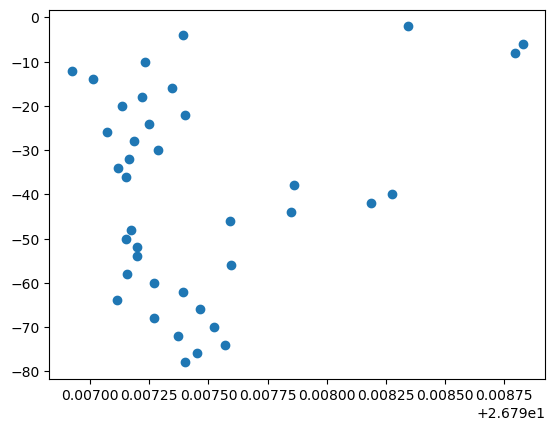

In [1057]:
plt.scatter(prof['SIG0'].values[:40], -prof['PRES_INTERPOLATED'].values[0:40])

In [1026]:

pres_ex, ct_ex, sa_ex, sig0_ex = prof['PRES_INTERPOLATED'].values, prof['CT'].values, prof['SA'].values, prof['SIG0'].values
energies = np.logspace(0, 2.5, 100)

In [1075]:
depth_mask = (prof['PRES_INTERPOLATED'] >= 10) & (prof['PRES_INTERPOLATED'] <= 1000)
prof_filtered = prof.where(depth_mask, drop = True)

In [1097]:
pres_ex, ct_ex, sa_ex, sig0_ex = prof2['PRES_INTERPOLATED'].values, prof2['CT'].values, prof2['SA'].values, prof2['SIG0'].values

In [1098]:
pres_new, dp_new, ct_new, sa_new = prepare_profiles(pres_ex, ct_ex, sa_ex)

In [1099]:
mld_from_energies(prof['PRES'].values, prof['CT'].values, prof['SA'].values, energies)

array([ 42.82681282,  43.34987656,  43.9041992 ,  44.49135563,
        45.57721561,  74.25428555,  75.82894761,  78.44084166,
        79.36444649,  80.34280444,  81.59154937,  82.754034  ,
        83.71808239,  86.66931964,  88.5363247 ,  89.74940921,
        93.58389607,  96.22610928,  97.69426109,  98.71081723,
        99.46790134, 100.26204954, 100.8185329 , 101.40844737,
       102.0333674 , 103.41850621, 104.94184622, 128.78993388,
       129.52269303, 130.14184227, 130.50967306, 130.89966752,
       131.31291556, 131.75087045, 132.19790814, 132.65063732,
       133.13037424, 133.63881431, 134.17280837, 134.72981283,
       135.32000108, 135.9454318 , 136.59278223, 137.2781602 ,
       138.00580428, 138.7971509 , 139.63572822, 140.53897568,
       141.50374365, 142.51016926, 143.56527631, 144.70878782,
       145.93876471, 147.44776642, 148.8782808 , 150.40954602,
       152.17525982, 153.91770768, 155.69937928, 157.43743989,
       159.15368875, 161.21966135, 162.81720396, 164.32

In [1094]:
def mld_from_energies(pres, ct, sa, energies):
    """
    For an array of energies, returns an array of MLDs of the profile
    for those energies
    """
    # Filter for data below 10 m
    start_i = np.argmax(pres >= 10)
    pres = pres[start_i:]
    ct = ct[start_i:]
    sa = sa[start_i:]
    
    
    # Shallowest layer thickness (negative to match sign convention)
    dp_0 = -(pres[0] - 1)
    # Center of shallowest layer just half of thickness (and positive)
    p_0 = -(dp_0/2)
    
    # Thickness array
    dp = np.array([dp_0] + list(np.full_like(pres, -2.0)))
    
    # Arrays with extrapolated surface values
    pres = np.array([p_0] + list(pres))
    ct = np.array([ct[0]] + list(ct))
    sa = np.array([sa[0]] + list(sa))
    
    # Calculate MLDs
    MLDs = [oml.mld_delta_pe(pres, dp, ct, sa, coord = 'pressure',
                            energy = e).item() for e in energies]
    
    return np.array(MLDs)

In [ ]:
for i, Energy in enumerate(energies):
    name = f'/swot/SUM05/jpope/mld_energy/energy_{i}.nc'
    mlds = oml.mld_delta_pe(
        pres_new.T, dp_new.T, ct_new.T, sa_new.T, coord='pressure', energy=Energy
    )
    print(mlds)

In [1083]:
def mld_from_energies(prof, energies):
    """
    For an array of energies, returns an array of MLDs of the profile
    for those energies
    """
    # Initialize values
    pres = prof['PRES_INTERPOLATED'].values
    ct = prof['CT'].values
    sa = prof['SA'].values
    sig0 = prof['SIG0'].values
    
    # Mask out any NaN values
    mask = ~np.isnan(pres) & ~np.isnan(ct) & ~np.isnan(sa) & ~np.isnan(sig0)
    pres, ct, sa, sig0 = pres[mask], ct[mask], sa[mask], sig0[mask]

    # Shallowest layer thickness (negative to match sign convention)
    dp_0 = -(pres[0] - 1)
    # Center of shallowest layer just half of thickness (and positive)
    p_0 = -(dp_0/2)
    
    # Thickness array
    dp = np.array([dp_0] + list(np.full_like(pres, -2.0)))
    # Arrays with extrapolated surface values
    pres = np.array([p_0] + list(pres))
    ct = np.array([ct[0]] + list(ct))
    sa = np.array([sa[0]] + list(sa))
    sig0 = np.array([sig0[0]] + list(sig0))
    # Calculate MLDs
    MLDs = [oml.mld_delta_pe(pres, dp, ct, sa, coord = 'pressure',
                            energy = e).item() for e in energies]
    
    return MLDs

In [1019]:
prof = ds_so.sel(N_PROF = 2342324)

In [1082]:
mld_values = mld_from_energies(prof_filtered, energies)

[-9 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2
 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2
 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2
 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2
 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2
 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2
 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2
 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2
 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2
 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2
 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2
 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2
 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2
 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2 -2

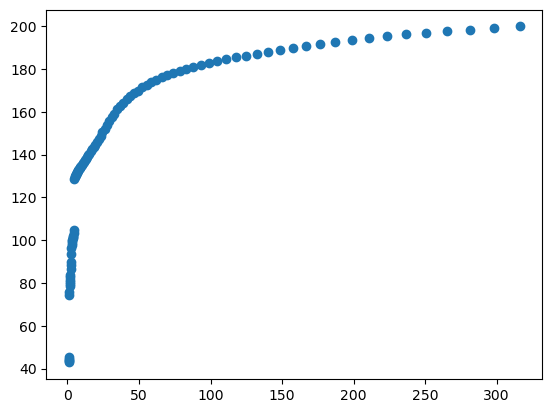

In [1081]:
plt.scatter(energies, mld_values)